<a href="https://colab.research.google.com/github/gon311/my-university-study/blob/main/%ED%8C%8C%EB%8D%B0%EC%B2%98_10_11%EA%B0%95_%EC%9D%B4%EC%83%81%EC%B9%98_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import seaborn as sns
import pandas as pd

tips = sns.load_dataset('tips')

print(tips)

print(tips.describe())

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.00000

1. 이상치 탐지 : 시각적 탐지

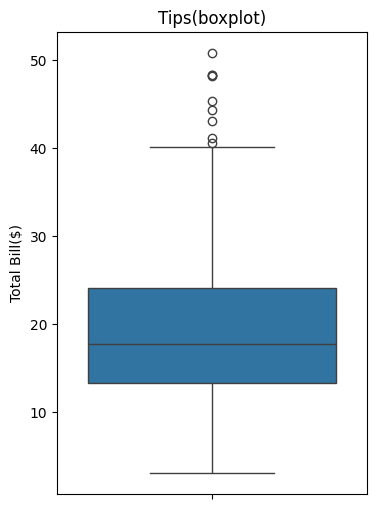

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize = (4, 6))

sns.boxplot(y = tips['total_bill'])
plt.title("Tips(boxplot)")
plt.ylabel('Total Bill($)')
plt.show()

💻 박스플롯에 대한 분석

도메인의 특성상 0 이하의 이상치는 발생할 수 없음

40 이상의 이상치에 대한 분석이 필요함

TypeError: regplot() got an unexpected keyword argument 'hue'

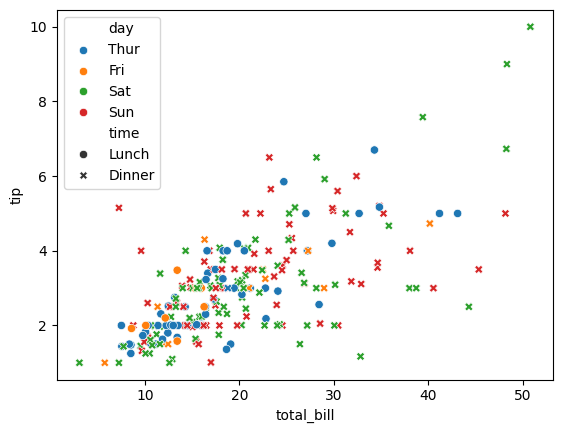

In [ ]:
# 산점도로 확인
## 산점도 : 2차원 이상치

import matplotlib.pyplot as plt

sns.scatterplot(x = tips['total_bill'], y = tips['tip'],
                hue = tips['day'],
                style = tips['time'])

plt.title("Tips(Scatter plot)")
plt.xlabel('Total Bill($)')
plt.ylabel('Tip($)')
plt.show()

💻 산점도에 대한 분석

도메인의 특성을 생각했을 때, total bill이 높을수록 tip도 높아지는 것은 자연스러워보임.

평균치에서 벗어나는 것으로 추정되는 점들의 요일이 일요일임을 고려했을때 이러한 이상치와 요일 사이에 상관관계가 있는지 확인해볼 필요가 있음

또한 식사 시간대와도 상관관계가 있는지 확인 필요



<Axes: xlabel='total_bill', ylabel='tip'>

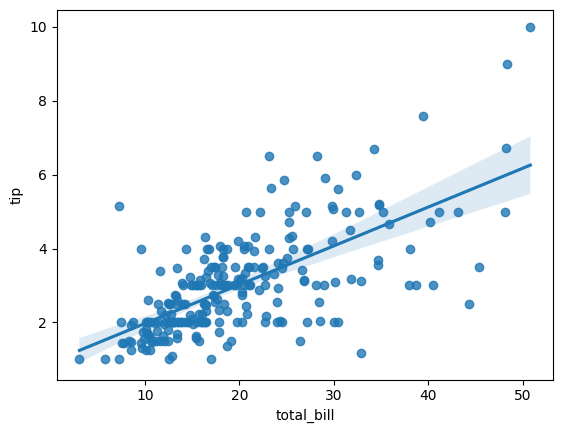

In [ ]:
# 선형 회귀모형으로 확인

import seaborn as sns

sns.regplot(x = tips['total_bill'], y = tips['tip'])


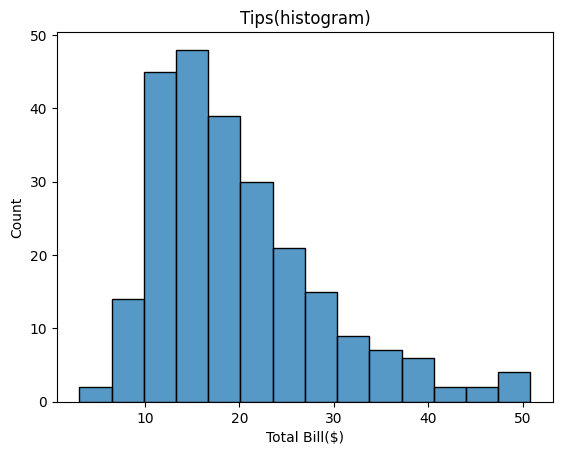

In [ ]:
# 히스토그램

sns.histplot(x = tips['total_bill'])

plt.title("Tips(histogram)")
plt.xlabel('Total Bill($)')
plt.ylabel('Count')
plt.show()

💻 히스토그램에 대한 분석

예상되는 그래프의 진행에서, 40후반-50초반의 가격을 지불한 데이터가 튀는 부분이 존재

2. 이상치 탐지 : 수치 기반 탐지

맥락과 도메인 지식에 따라 기준은 달라짐

암묵적 시작 기준으로 사분위 범위(IQR) 사용

    x > Q3 + 1.5 * IQR : 이상치 상한 초과

    X < Q1 - 1.5 * IQR : 이상치 하한 미만

    👑 분포 가정이 불필요

In [ ]:
# 사분위 범위(IQR) 사용

Q1 = tips['total_bill'].quantile(0.25)
Q3 = tips['total_bill'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = tips[(tips['total_bill'] < lower_bound) | (tips['total_bill'] > upper_bound)]
print(f"이상치 개수 : {outliers.shape[0]}")
print(outliers['total_bill'])

이상치 개수 : 9
59     48.27
102    44.30
142    41.19
156    48.17
170    50.81
182    45.35
184    40.55
197    43.11
212    48.33
Name: total_bill, dtype: float64


정규분포를 가정, 등장할 확률이 지나치게 낮은 값을 이상치로 설정.

    |Z-score| > 3 에서 시작
    
    👑 정규분포 가정 필요

In [ ]:
# Z-점수 기반
import numpy as np
tb = tips['total_bill']
mean = tb.mean()   # 평균
std = tb.std()     # 표준오차
thresould = 3      # 임계값 (3표준편차)
z_scores = (tb - mean) / std
outliers_z = tips[np.abs(z_scores) > thresould]
print(f"이상치 개수: {outliers_z.shape[0]}")
print(outliers_z['total_bill'])


이상치 개수: 4
59     48.27
156    48.17
170    50.81
212    48.33
Name: total_bill, dtype: float64


# 11. 이상치 처리

## 이상치 제거

⁉ 이상치를 유지할것인가 제거할것이가
- 정말 이상치인가?
- 이상치라면 어떤 부정적인 효과를 가져오는가?
- 제거할 것인가? 제거한다면 완전 제거 vs 부분 제거?

고려해야 할 부분
    
    - 단순 측정 오류로 발생한 이상치라면 결측치로 간주
    - 대부분은 도메인 지식을 바탕으로 판단하여 처리해야 한다
    - 이상치 처리 내역은 기록할 필요가 있다
    ? 주기적으로 일어나는 이상치는 패턴이 될 수 있다.

### IQR 기준으로 이상치를 제거

In [ ]:
# IQR 기준으로 이상치 제거

tips_clean = tips[(tips['total_bill'] >= lower_bound) & (tips['total_bill'] <= upper_bound)]
print(tips.shape, "->", tips_clean.shape)

print("원래 평균: ", tips['total_bill'].mean())
print("제거 후 평균: ", tips_clean['total_bill'].mean())
print("원래 중앙값", tips['total_bill'].median())
print("제거 후 중앙값", tips_clean['total_bill'].median())

# 평균에 비해 중앙값을 크게 영향을 받지 않음

(244, 7) -> (235, 7)
원래 평균:  19.78594262295082
제거 후 평균:  18.798680851063832
원래 중앙값 17.795
제거 후 중앙값 17.46


### Z-score 기준으로 단순 제거
✅ Z-score를 쓰려면 정규분포로 변환이 필요하다.

    tips와 같이 돈과 관련된 데이터들을 정규분포를 따르지 않는 경우들이 많다.
    이럴때는 Z-scorer가 아니라 IQR를 기준으로 하는 것이 더 바람직하다.

In [ ]:
# Z-score

threshold = 3
z_scores = (tips['total_bill'] - mean) / std
tips_clean_z = tips[np.abs(z_scores) <= threshold]
print(tips.shape, "->", tips_clean_z.shape)
print("원래 평균: ", tips['total_bill'].mean())
print("제거 후 평균: ", tips_clean_z['total_bill'].mean())
print("원래 중앙값", tips['total_bill'].median())
print("제거 후 중앙값", tips_clean_z['total_bill'].median())

(244, 7) -> (240, 7)
원래 평균:  19.78594262295082
제거 후 평균:  19.30079166666667
원래 중앙값 17.795
제거 후 중앙값 17.55


"중앙값이 평균이 수렴" 한다는 것이 언제나 통계적으로 긍정적인 것은 아니다.

분포의 특성이 제거되었다고 판단할 수도 있다.

## 이상치 효과 줄이기

이상치를 유지하면서 전체 데이터 값을 변환하여 이상치의 영향을 줄임.
    개별 값의 크기는 중요치 않고 분포 상의 특성이 중요한 경우 사용

### 스케일링 기법
    특성 간의 영향력을 균등하게 하고, 모델의 성능을 향상

EX)
[RobustScaler] : Sklearn package에 포함된 강건 스케일러

    : 중앙값에서부터 몇사분위 범위만큼 빠져있는가? 를 확인

In [ ]:
from sklearn.preprocessing import RobustScaler

target = tips[['total_bill', 'tip']]

print("원본\n", tips.head())
print(tips.describe()) # NOTE : median : 17.795

scaler = RobustScaler()
target_scaled = scaler.fit_transform(target)
print("스케일링\n", target_scaled[:5])

원본
    total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4
       total_bill         tip        size
count  244.000000  244.000000  244.000000
mean    19.785943    2.998279    2.569672
std      8.902412    1.383638    0.951100
min      3.070000    1.000000    1.000000
25%     13.347500    2.000000    2.000000
50%     17.795000    2.900000    2.000000
75%     24.127500    3.562500    3.000000
max     50.810000   10.000000    6.000000
스케일링
 [[-0.07467532 -1.2096    ]
 [-0.69155844 -0.7936    ]
 [ 0.29823748  0.384     ]
 [ 0.54591837  0.2624    ]
 [ 0.63033395  0.4544    ]]


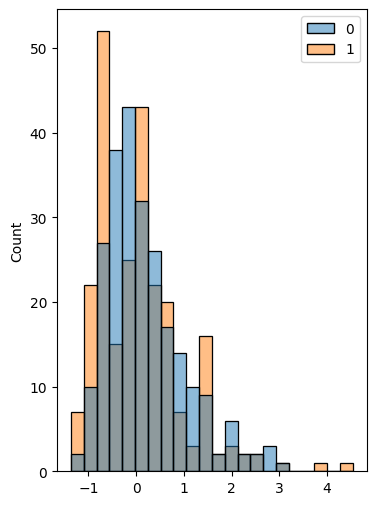

In [ ]:
import matplotlib.pyplot as pit
import seaborn as sns

pit.figure(figsize=(4,6))

# sns.histplot(target['total_bill'])
sns.histplot(target_scaled)
pit.show()

## 중복치 제거

### 중복치(duplicate)란?
    동일한 행(record)이 데이터셋에 반복 : 중복치일 가능성이 존재
    => uid와 같이 unique key 를 부여해서 중복 여부 확인
    해당 패턴이 과대 표집되는 문제가 발생할 수 있으므로 발견 즉시 제거하는 것이 원칙.


In [ ]:
import pandas as pd

data = {'Name': ['kim', 'lee', 'lee', 'choi'],
        'Score' : [90, 85, 85, 95]}
df = pd.DataFrame(data)

print(df)
print(df.duplicated()) # NOTE: 각 행이 이전 행들과 중복이면 True
df.drop_duplicates(inplace=True) # NOTE: 원본 데이터에 바로 반영
print(df)

   Name  Score
0   kim     90
1   lee     85
2   lee     85
3  choi     95
0    False
1    False
2     True
3    False
dtype: bool
   Name  Score
0   kim     90
1   lee     85
3  choi     95
